In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Check Stats for mapped singer ID


In [2]:
# load dataframe from /home/aik2/sc-rawnet3/datasets/12m/12m-youtube-wav-with-local-and-singer-id.csv
df = pd.read_csv('/home/aik2/sc-rawnet3/datasets/12m/12m-youtube-wav-with-local-and-singer-id.csv')

# print headers of each column
print(df.columns.tolist())



['index', 'title', 'artist_name', 'youtube_link', 'gcs_link', 'local_file_name', 'singer_id']


In [7]:
# Print total number of unique singer IDs
print(f"Total number of unique singer IDs: {df['singer_id'].nunique()}")

# Get each singer_id's corresponding number of songs and their artist names, sorted by number of songs in descending order
singer_id_counts = df.groupby('singer_id').agg({
    'artist_name': ['count', lambda x: x.str.lower().unique()]
}).reset_index()

# Flatten column names
singer_id_counts.columns = ['singer_id', 'song_count', 'artist_names']

# Sort by number of songs in descending order
singer_id_counts = singer_id_counts.sort_values(by='song_count', ascending=False)

# Print the top 100 singer_ids by number of songs
print("\nTop 100 singer IDs by number of songs:")
for i, row in singer_id_counts.head(100).iterrows():
    print(f"{row['singer_id']}: {row['song_count']} songs, artist names: {row['artist_names']}")

# randomly sample 100 singer_ids that has songs around 10-20
sampled_singer_ids = singer_id_counts[singer_id_counts['song_count'].between(10, 20)].sample(100)
print(sampled_singer_ids)

# Show some additional statistics
print(f"\nSinger ID with most songs: {singer_id_counts.iloc[0]['singer_id']} ({singer_id_counts.iloc[0]['song_count']} songs)")
print(f"Average songs per singer ID: {singer_id_counts['song_count'].mean():.2f}")
print(f"Median songs per singer ID: {singer_id_counts['song_count'].median():.2f}")

Total number of unique singer IDs: 59190

Top 100 singer IDs by number of songs:
id57368: 150 songs, artist names: ['zaperoko la resistencia salser']
id08713: 150 songs, artist names: ['aviators']
id29754: 150 songs, artist names: ['kirti singh']
id17790: 150 songs, artist names: ['e.l']
id34906: 150 songs, artist names: ['maría ilusíon']
id54265: 150 songs, artist names: ['tyree thomas']
id40545: 150 songs, artist names: ['no use for a name']
id40947: 150 songs, artist names: ['nurmuhammet meredow']
id56222: 150 songs, artist names: ['work drugs']
id53050: 150 songs, artist names: ['tibob pour nazareth']
id14293: 150 songs, artist names: ['coty']
id24444: 150 songs, artist names: ['icon magano']
id54292: 150 songs, artist names: ['tørfisk']
id18236: 150 songs, artist names: ['el heredero']
id20237: 150 songs, artist names: ['formatia nuntasii']
id58750: 150 songs, artist names: ['梦之旅演唱组合']
id57857: 150 songs, artist names: ['özlem ajans sanatçıları']
id51606: 150 songs, artist names: 

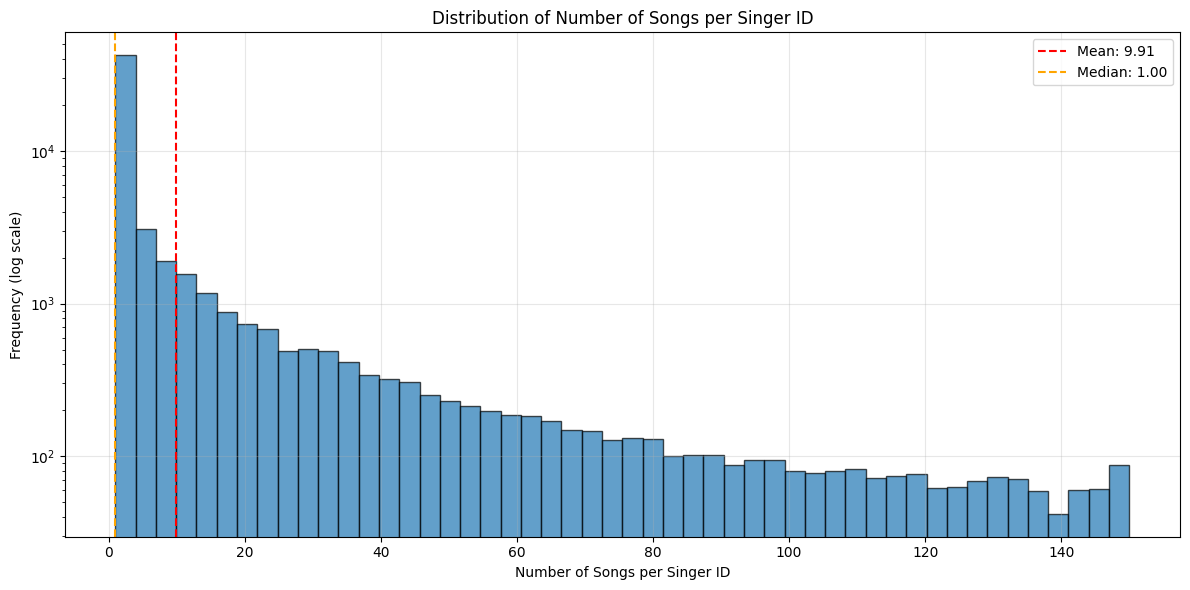

Statistics for songs per singer ID:
Total singer IDs: 59190
Min songs: 1
Max songs: 150
Mean songs: 9.91
Median songs: 1.00
Standard deviation: 22.74

Singer IDs with only 1 song: 35546 (60.1%)
Singer IDs with multiple songs: 23644 (39.9%)


In [5]:
# Plot distribution of number of songs per singer ID. Use histogram with log scale
plt.figure(figsize=(12, 6))

# Create histogram with log scale on y-axis
plt.hist(singer_id_counts['song_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Songs per Singer ID')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Number of Songs per Singer ID')
plt.yscale('log')  # Set y-axis to log scale
plt.grid(True, alpha=0.3)

# Add some statistics as text on the plot
plt.axvline(singer_id_counts['song_count'].mean(), color='red', linestyle='--', 
           label=f'Mean: {singer_id_counts["song_count"].mean():.2f}')
plt.axvline(singer_id_counts['song_count'].median(), color='orange', linestyle='--', 
           label=f'Median: {singer_id_counts["song_count"].median():.2f}')

plt.legend()
plt.tight_layout()
plt.show()

# Print some additional statistics
print(f"Statistics for songs per singer ID:")
print(f"Total singer IDs: {len(singer_id_counts)}")
print(f"Min songs: {singer_id_counts['song_count'].min()}")
print(f"Max songs: {singer_id_counts['song_count'].max()}")
print(f"Mean songs: {singer_id_counts['song_count'].mean():.2f}")
print(f"Median songs: {singer_id_counts['song_count'].median():.2f}")
print(f"Standard deviation: {singer_id_counts['song_count'].std():.2f}")

# Show how many singer IDs have only 1 song vs multiple songs
single_song = (singer_id_counts['song_count'] == 1).sum()
multiple_songs = (singer_id_counts['song_count'] > 1).sum()
print(f"\nSinger IDs with only 1 song: {single_song} ({single_song/len(singer_id_counts)*100:.1f}%)")
print(f"Singer IDs with multiple songs: {multiple_songs} ({multiple_songs/len(singer_id_counts)*100:.1f}%)")

In [9]:
# Print total number of singers with 2-4 songs
print(f"Total number of singers with 2-4 songs: {singer_id_counts[singer_id_counts['song_count'].between(2, 4)].shape[0]}")

Total number of singers with 2-4 songs: 8140


## Original Dataset Stats 
Before filter, sad, and deduplication

In [3]:
# load file /home/aik2/sc-rawnet3/datasets/12m/12m-youtube-wav.csv and open
df = pd.read_csv('/home/aik2/sc-rawnet3/datasets/12m/12m-youtube-wav.csv')

# print headers of each column
print(df.columns.tolist())

['index', 'title', 'artist_name', 'youtube_link', 'gcs_link']


In [4]:
dir_path = "./sad"

# check if each folder's name in dir_path is in 

In [7]:
# print length of df
print(f"Total songs in dataset: {len(df)}")

# print total number of unique artist names
print(f"Unique artist names: {df['artist_name'].nunique()}")

# print total number of unique artist names case insensitive
print(f"Unique artist names (case insensitive): {df['artist_name'].str.lower().nunique()}")

# print the number of unique artist names that contain "feat."
print(f"Contains 'feat.': {df[df['artist_name'].str.contains('feat.', na=False, case=False)]['artist_name'].nunique()}")

# print the number of unique artist names that has "Orchestra", "Philharmonic", "Chamber", "Ensemble", "Piano", "Symphony", "Concerto", "choir", "chorus" in the name, Case insensitive
print(f"Contains classical keywords: {df[df['artist_name'].str.contains('Orchestra|Philharmonic|Chamber|Ensemble|Piano|Symphony|Concerto|choir|chorus', case=False, na=False)]['artist_name'].nunique()}")

# count unique artist names that contains "DJ"
print(f"Contains 'DJ ': {df[df['artist_name'].str.contains('DJ ', case=False, na=False)]['artist_name'].nunique()}")

# count unique artist names that contains "vs."
print(f"Contains 'vs.': {df[df['artist_name'].str.contains('vs.', case=False, na=False)]['artist_name'].nunique()}")

# count unique artist names that contains "' '"
print(f"Contains space between quotes (' '): {df[df['artist_name'].str.contains('\' \'', na=False)]['artist_name'].nunique()}")

# print 50 examples of artist names that contains space between quotes (' ')
print(df[df['artist_name'].str.contains('\' \'', na=False)]['artist_name'].head(50).tolist())

# count unique artist names that contains "&"
print(f"Contains '&': {df[df['artist_name'].str.contains('&', case=False, na=False)]['artist_name'].nunique()}")

# count artist names that contains "unknown", "anonymous", "unknown artist"
print(f"Contains 'unknown/anonymous': {df[df['artist_name'].str.contains('unknown|anonymous|unknown artist', case=False, na=False)]['artist_name'].nunique()}")

# count artist names that contains "with"
print(f"Contains 'with': {df[df['artist_name'].str.contains('with', case=False, na=False)]['artist_name'].nunique()}")

# count artist names that contains " and "
print(f"Contains ' and ': {df[df['artist_name'].str.contains(' and ', case=False, na=False)]['artist_name'].nunique()}")

# print 50 examples of artist names that contains " and " in separate rows
contains_and = df[df['artist_name'].str.contains(' and ', case=False, na=False)]
contains_and['artist_name'].str.split(' and ').explode().head(50).tolist()

# count artist names that contains ","
print(f"Contains ',': {df[df['artist_name'].str.contains(',', case=False, na=False)]['artist_name'].nunique()}")

# print 50 examples of artist names that contains "," in separate rows
print(df[df['artist_name'].str.contains(',', case=False, na=False)]['artist_name'].head(50).tolist())

# Count NaN artist names
nan_count = df['artist_name'].isna().sum()
nan_percentage = (nan_count / len(df)) * 100
print(f"NaN artist names: {nan_count} ({nan_percentage:.2f}% of total songs)")

Total songs in dataset: 736157
Unique artist names: 93422
Unique artist names (case insensitive): 90466
Contains 'feat.': 656
Contains classical keywords: 1083
Contains 'DJ ': 7031
Contains 'vs.': 236
Contains space between quotes (' '): 17084
["['The Guru Project & Tom Franke vs. Coco Star' 'Tom Franke']", "['Pitsa Papadopoulou' 'Pix Lax']", "['Tom Franke' 'Andy B. Jones']", "['DJ Hamida' 'Anas Yan' 'Silva']", "['Mea' 'Tom Franke']", "['Gianluca Luisi' 'Johann Sebastian Bach']", "['Culture Shock' 'Josh Parkinson']", "['Daniel Hope' 'Royal Stockholm Philharmonic Orchestra' 'Sakari Oramo']", "['Di Propósito' 'BIN' 'Ajaxx']", "['Gianluca Luisi' 'Johann Sebastian Bach']", "['East Sunrise' 'Magnetic Brothers']", "['DaPaz' 'Di Propósito' 'Medellin']", "['Gianluca Luisi' 'Johann Sebastian Bach']", "['DJ S.K.T' 'Josh Parkinson']", "['Gianluca Luisi' 'Johann Sebastian Bach']", "['Autograf' 'Klingande' 'Dragonette']", "['Sakari Oramo' 'Jean Sibelius']", "['Ange' 'ID 49' 'Magnetic Brothers']", "

Sample of rows with NaN artist names:
Title: The Phone Booth
YouTube link: https://www.youtube.com/watch?v=tKPzRjlCmNw
GCS link: gs://12m-youtube/songs_wav/The_Phone_Booth-NA-tKPzRjlCmNw.wav
---
Title: Dawn Basil XM Remix
YouTube link: https://www.youtube.com/watch?v=8Smp5CoOiYQ
GCS link: gs://12m-youtube/songs_wav/Dawn_Basil_XM_Remix-NA-8Smp5CoOiYQ_3min.wav
---
Title: Interstellar Katrik Remix
YouTube link: https://www.youtube.com/watch?v=_owAstCOcIQ
GCS link: gs://12m-youtube/songs_wav/Interstellar_Katrik_Remix-NA-_owAstCOcIQ_3min.wav
---
Title: Interstellar
YouTube link: https://www.youtube.com/watch?v=gzpE-bAhhhA
GCS link: gs://12m-youtube/songs_wav/Interstellar-NA-gzpE-bAhhhA_3min.wav
---
Title: Interstellar Derrick Meyer Remix
YouTube link: https://www.youtube.com/watch?v=5nRHr9oQ-5M
GCS link: gs://12m-youtube/songs_wav/Interstellar_Derrick_Meyer_Remix-NA-5nRHr9oQ-5M_3min.wav
---


In [9]:
def count_artist_names_with_filters(df):
    # All filter patterns in one list
    filters = [
        'feat\\.', 
        'Orchestra|Philharmonic|Symphonica|Chamber|Ensemble|Piano|string|strings|Symphony|Symphonie|symphon|Concerto|choir|chorus|Philharmoniker',
        '交响|乐团|协奏曲|合唱',
        'DJ |D\\.J\\.',  # Matching both "DJ " and "D.J."
        'vs\\.',
        '\' \'',
        '&',
        'unknown|anonymous|unknown artist',
        'with', 'collection', 'collective', ','
    ]
    
    # Combine all patterns with OR operator
    combined_pattern = '|'.join(filters)
    
    # Create masks for both pattern matches and NaN values
    pattern_mask = df['artist_name'].str.contains(combined_pattern, case=False, na=False)
    nan_mask = df['artist_name'].isna()
    
    # Count NaN values
    nan_count = nan_mask.sum()
    nan_percentage = (nan_count / len(df)) * 100
    
    # Combine both masks
    filter_mask = pattern_mask | nan_mask
    
    # Count unique artist names matching any filter (excluding NaN)
    filtered_artists = df[pattern_mask]['artist_name'].unique()
    filtered_artist_count = len(filtered_artists)
    
    # Count songs (rows) with filtered artists or NaN values
    filtered_song_count = filter_mask.sum()
    
    # Calculate percentages
    total_artists = df['artist_name'].nunique()
    total_songs = len(df)
    artist_percentage = (filtered_artist_count / total_artists) * 100
    song_percentage = (filtered_song_count / total_songs) * 100
    
    # Print results
    print(f"Total unique artist names: {total_artists}")
    print(f"NaN artist names: {nan_count} ({nan_percentage:.2f}% of total songs)")
    print(f"Artist names matching at least one filter: {filtered_artist_count} ({artist_percentage:.2f}%)")
    print(f"\nTotal songs in dataset: {total_songs}")
    print(f"Songs with filtered artists or NaN: {filtered_song_count} ({song_percentage:.2f}%)")
    
    # Include NaN in the returned filtered artists set
    return filtered_artists

filtered_artists = count_artist_names_with_filters(df)

# Get all unique artists
all_artists = df['artist_name'].unique()

# Convert filtered_artists to a set for faster lookup
filtered_artists_set = set(filtered_artists)

# Get artists that are NOT in filtered_artists and are not NaN
unfiltered_artists = [artist for artist in all_artists 
                     if artist not in filtered_artists_set and not pd.isna(artist)]

# Count unique artists (case sensitive)
print(f"Number of unique unfiltered artists (case sensitive): {len(set(unfiltered_artists))}")

# Count unique artists case-insensitively while handling NaN values
unfiltered_artists_case_insensitive = set()
for artist in unfiltered_artists:
    if isinstance(artist, str):  # Check if it's a string
        unfiltered_artists_case_insensitive.add(artist.lower())
    else:
        # For non-string values (like NaN), just add them as is
        unfiltered_artists_case_insensitive.add(artist)

print(f"Number of unique unfiltered artists (case insensitive): {len(unfiltered_artists_case_insensitive)}")

Total unique artist names: 93422
NaN artist names: 17 (0.00% of total songs)
Artist names matching at least one filter: 27854 (29.82%)

Total songs in dataset: 736157
Songs with filtered artists or NaN: 64994 (8.83%)
Number of unique unfiltered artists (case sensitive): 65568
Number of unique unfiltered artists (case insensitive): 63042


In [12]:
# Print 10 random examples of pairs that differ only by case
import random

# Filter to only include entries with multiple case variations
duplicate_cases = {k: v for k, v in case_pairs.items() if len(v) > 1}

# Get a random sample of keys
print("Random examples of artist names that differ only by case:")
if duplicate_cases:
    # Get a random sample of keys (up to 10)
    sample_size = min(10, len(duplicate_cases))
    sample_keys = random.sample(list(duplicate_cases.keys()), sample_size)
    
    for lowercase in sample_keys:
        variations = duplicate_cases[lowercase]
        print(f"Lowercase: '{lowercase}'")
        for v in variations[:5]:  # Limit to 5 variations per group
            print(f"  - '{v}'")
        print()
else:
    print("No case-sensitive duplicates found.")

Random examples of artist names that differ only by case:
Lowercase: 'r2m'
  - 'R2M'
  - 'R2m'

Lowercase: 'bryant'
  - 'Bryant'
  - 'BryAnt'

Lowercase: 'aquakey'
  - 'Aquakey'
  - 'AQUAKEY'

Lowercase: 'stardust revue'
  - 'Stardust Revue'
  - 'STARDUST REVUE'

Lowercase: '['mc 7kssio']'
  - '['MC 7Kssio']'
  - '['Mc 7Kssio']'
  - '['mc 7kssio']'
  - '['Mc 7kssio']'

Lowercase: 'sunami'
  - 'Sunami'
  - 'sunami'
  - 'SUNAMI'

Lowercase: 'los primos de huehuetan'
  - 'Los Primos De Huehuetan'
  - 'Los Primos de Huehuetan'

Lowercase: 'rezz'
  - 'REZZ'
  - 'Rezz'

Lowercase: 'smew'
  - 'Smew'
  - 'SMEW'

Lowercase: 'velha guarda da portela'
  - 'VELHA GUARDA DA PORTELA'
  - 'Velha Guarda Da Portela'
  - 'Velha Guarda da Portela'



In [102]:

# Sample random artist names from unfiltered artists
# Random sample from unfiltered artists (passed filtering)
sampled_artists = pd.Series(unfiltered_artists).sample(min(10, len(unfiltered_artists))).tolist()
for artist in sampled_artists:
    print(artist)

Yoga Meditation Guru Spiritual
Mc MagnataOriginal Brisa081
['Venke Knutson']
周志宏 羅啟瑞 薛菁麗 and 莫白
['Kristiwa Napu']
Vaibhav Bagmar Balotra
P110 B_real.11
FR3SH TrX Rayman Rave
Jarren Benton Demrick Johnny S
ZERXMANE WoLRa


In [92]:
# List of artists to check with multiple name variations
artists_to_check = [
    ('陈奕迅', '陳奕迅', 'Eason Chan'),
    ('周杰伦', '周杰倫', 'Jay Chou'),
    ('王力宏', 'Leehom Wang'),
    ('陶喆', 'David Tao')
]

# Function to check if an artist is in the dataset
def check_artist(name):
    # Case insensitive search for the artist name
    matches = df[df['artist_name'].str.contains(name, case=False, na=False)]
    count = len(matches)
    
    if count > 0:
        print(f"✓ '{name}' found with {count} songs")
        # Show a few examples if any are found
        if count > 0:
            print("  Examples:")
            for _, row in matches.head(3).iterrows():
                print(f"  - {row['artist_name']}: {row['title']}")
    else:
        print(f"✗ '{name}' not found")
    
    return count > 0

# Check each artist with all name variations
print("Checking for artists in the dataset:\n")

for artist_names in artists_to_check:
    # Display all variations of the artist's name
    print(f"Artist: {' / '.join(artist_names)}")
    
    # Check each name variation
    found = False
    for name in artist_names:
        if check_artist(name):
            found = True
    
    if not found:
        print(f"→ {' / '.join(artist_names)} is not in the dataset")
    
    print("")  # Add a blank line between artists

Checking for artists in the dataset:

Artist: 陈奕迅 / 陳奕迅 / Eason Chan
✗ '陈奕迅' not found
✓ '陳奕迅' found with 128 songs
  Examples:
  - 陳奕迅: 孤勇者 《英雄聯盟：雙城之戰》動畫劇集中文主題曲 - Warrior of the Darkness
  - 陳奕迅: 富士山下
  - 陳奕迅: 十年 OT- 明年今日
✓ 'Eason Chan' found with 15 songs
  Examples:
  - Eason Chan: 我的快樂時代 - Wo De Kuai Le Shi Dai
  - Eason Chan: 與我常在 - Yu Wo Chang Zai
  - Eason Chan: 天下無雙 - Tian Xia Mo Shuang

Artist: 周杰伦 / 周杰倫 / Jay Chou
✗ '周杰伦' not found
✓ '周杰倫' found with 3 songs
  Examples:
  - 周杰倫 費玉清: 千里之外
  - 溫嵐周杰倫 Landy Wen and Jay Chou: 屋頂 男聲- 周杰倫
  - 溫嵐周杰倫 Landy Wen and Jay Chou: 祝我生日快樂 無與倫比演唱會對唱版
✓ 'Jay Chou' found with 2 songs
  Examples:
  - 溫嵐周杰倫 Landy Wen and Jay Chou: 屋頂 男聲- 周杰倫
  - 溫嵐周杰倫 Landy Wen and Jay Chou: 祝我生日快樂 無與倫比演唱會對唱版

Artist: 王力宏 / Leehom Wang
✗ '王力宏' not found
✗ 'Leehom Wang' not found
→ 王力宏 / Leehom Wang is not in the dataset

Artist: 陶喆 / David Tao
✓ '陶喆' found with 16 songs
  Examples:
  - 陶喆 盧廣仲: 那個女孩
  - 陶喆: 一念之間
  - 陶喆 關詩敏: 好好說再見
✓ 'David Tao' found with 125 songs


In [86]:
total = df['artist_name'].nunique()
single = df[df['artist_name'].str.match(single_singer_pattern, na=False)]['artist_name'].nunique()
multi = total - single
print(f"Single artists: {single} ({(single/total)*100:.1f}%)")
print(f"Multiple artists: {multi} ({(multi/total)*100:.1f}%)")

NameError: name 'single_singer_pattern' is not defined

In [17]:
import json
import random

# Load the singer mapping
with open('/home/aik2/sc-rawnet3/datasets/12m/singer_id_mapping_filtered.json', 'r') as f:
    singer_mapping = json.load(f)

# Get all singer IDs
singer_ids = list(singer_mapping.keys())

# Sample 10 random IDs
sampled_ids = random.sample(singer_ids, 10)

# Print info for each sampled ID
print("Information for 10 randomly sampled singer IDs:")
for singer_id in sampled_ids:
    print(f"\n{singer_id}:")
    print(f"  Lowercase: '{singer_mapping[singer_id]['lowercase']}'")
    print(f"  Variations: {singer_mapping[singer_id]['variations']}")


# check if rezz is in the json file


Information for 10 randomly sampled singer IDs:

id57084:
  Lowercase: 'yuber adams'
  Variations: ['Yuber Adams']

id26661:
  Lowercase: 'jk beats dr'
  Variations: ['JK Beats DR']

id26238:
  Lowercase: 'jeff fullyauto and iq'
  Variations: ['Jeff Fullyauto and IQ']

id54812:
  Lowercase: 'vali vijelie laura vass'
  Variations: ['Vali Vijelie Laura Vass']

id36404:
  Lowercase: 'mc paiva zs mc cebezinho mc pe'
  Variations: ['Mc Paiva ZS MC Cebezinho MC PE']

id57155:
  Lowercase: 'yung da producer'
  Variations: ['Yung Da Producer']

id01266:
  Lowercase: '['coastal']'
  Variations: ["['Coastal']"]

id18256:
  Lowercase: 'el leo pa alex zurdo'
  Variations: ['El Leo Pa Alex Zurdo']

id33277:
  Lowercase: 'm. ashraf'
  Variations: ['M. Ashraf']

id29714:
  Lowercase: 'kingsmizzy rooga'
  Variations: ['KingSmizzy rooga']


In [18]:
# check if rezz is in the json file
print("\nChecking for artist 'rezz'...")
search_name = "rezz"
found = False

# Method 1: Check for exact lowercase match
for singer_id, info in singer_mapping.items():
    if info["lowercase"] == search_name:
        print(f"Found exact match with ID: {singer_id}")
        print("Raw JSON entry:")
        print({singer_id: info})
        found = True
        break

if not found:
    print(f"No exact match for '{search_name}'")
    
    # Method 2: Check for substring match in lowercase or variations
    print(f"\nLooking for artists containing '{search_name}'...")
    matches = {}
    
    for singer_id, info in singer_mapping.items():
        if search_name in info["lowercase"]:
            matches[singer_id] = info
            continue
            
        for variation in info["variations"]:
            if search_name.lower() in variation.lower():
                matches[singer_id] = info
                break
    
    if matches:
        print(f"Found {len(matches)} artists containing '{search_name}':")
        print("Raw JSON entries:")
        print(matches)
    else:
        print(f"No artists containing '{search_name}' found in the dataset.")


Checking for artist 'rezz'...
Found exact match with ID: id45286
Raw JSON entry:
{'id45286': {'lowercase': 'rezz', 'variations': ['Rezz', 'REZZ']}}


In [ ]:
# Check for songs with "rezz" in artist_name
import pandas as pd

# Load the CSV file
csv_path = '/home/aik2/sc-rawnet3/datasets/12m/12m-youtube-wav-with-local-and-singer-id.csv'
print(f"Loading data from {csv_path}...")
df = pd.read_csv(csv_path)

# Filter for songs where artist_name contains "rezz" (case insensitive)
search_term = "rezz"
rezz_songs = df[df['artist_name'].str.contains(search_term, case=False, na=False)]

# Print count
print(f"\nFound {len(rezz_songs)} songs with '{search_term}' in artist_name")

# Print folder names (if they exist)
if len(rezz_songs) > 0:
    print("\nFolder names for these songs:")
    for idx, row in rezz_songs.iterrows():
        folder_name = row['local_file_name']
        artist = row['artist_name']
        title = row['title']
        print(f"Folder: {folder_name}")
        print(f"Artist: {artist}")
        print(f"Title: {title}")
        print("-" * 50)
else:
    print(f"No songs with '{search_term}' in artist_name found.")